# Example D: Grouped Bar Plot with Statistical Significance Annotation

This example features code to generate the following figure:

![example_d](img/example_d.png)


First we include a cell to import the packages we'll be using:

In [1]:
import matplotlib.pyplot as plt
import starbars

import numpy as np

Here we define the data we'd like to plot:

In [2]:
# data taken from https://allisonhorst.github.io/palmerpenguins/

species = ("Adelie", "Chinstrap", "Gentoo")

penguin_means = {
    'Bill Depth': (18.35, 18.43, 14.98),
    'Bill Length': (38.79, 48.83, 47.50),
    'Flipper Length': (189.95, 195.82, 217.19),
}

# Dummy values and not actually calculated from dataset:
attribute_std_err = {
    'Bill Depth': (2.57, 1.62, 0.35),
    'Bill Length': (4.26, 3.75, 5.82),
    'Flipper Length': (10.72, 4.91, 17.92)
}

# Dummy values and not actually calculated from dataset:
annotations = {
    'Bill Depth': [],
    'Bill Length': [],
    'Flipper Length': [(0, 1, 0.3), (1, 2, 0.02), (0, 2, 0.002)] # Format is [(<bar_index_1>, <bar_index_2>, <significance value>), (...), ...]
}

Calling `plt.subplots()` allows us to separate the figure space and plotted axes into two separate objects (`fig` and `ax`, respectively). This is useful for when multiple plots (`ax` objects) need to be displayed on a single figure (`fig` object). In this example, we only show one bar plot on the figure using `ax.bar()` with the `species` tuple as the x axis (or bars) and the "Bill Depth" data for each penguin species to start.

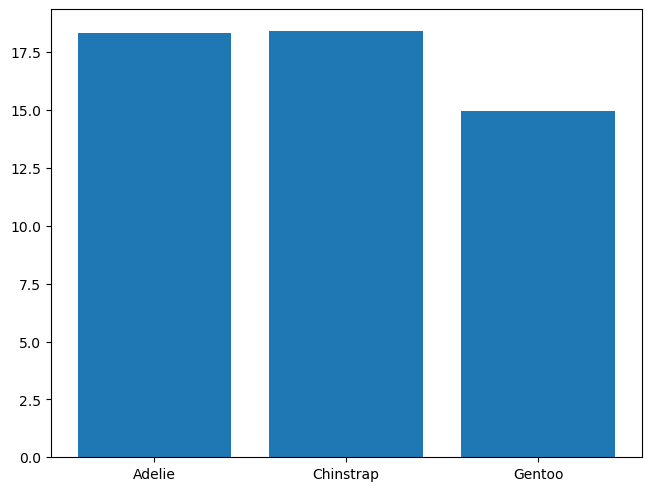

In [6]:
fig, ax = plt.subplots(layout='constrained')
im = ax.bar(species, penguin_means['Bill Depth'])

Moving to a grouped bar plot requires us to iterate through the penguin_means dictionary we defined and plot each attribute as a separate `ax.bar()` instance. We use `bar_ticks` instead of the species labels directly to numerically space out each bar to our liking.

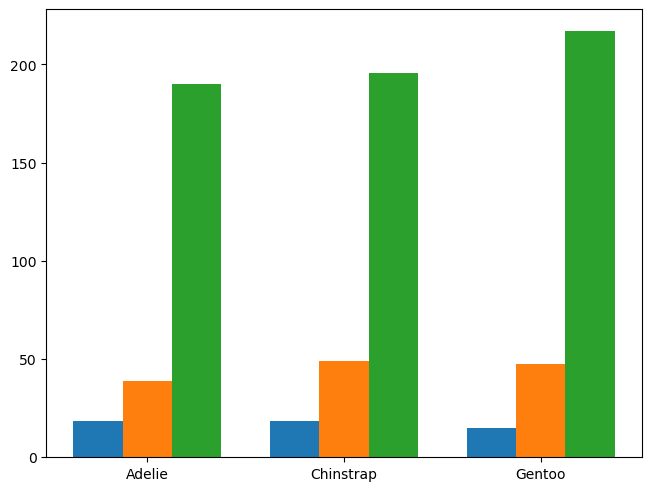

In [ ]:
fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(species)) # Get bar label positions as numeric values
width = 0.25 # Compress each bar width to accommodate grouping
multiplier = 0 # Iterates the offset for each new bar in a group

# We can iterate through each key, val pair in the penguin_means dictionary
# and plot each measurement as a bar grouped by species:
for attribute, measurement in penguin_means.items():
    
    offset = width * multiplier
    bar_ticks = x + offset

    rects = ax.bar(bar_ticks, measurement, width,
                   label=attribute)
    
    multiplier += 1

ax.set_xticks(x + width, species) # Show "x-ticks" as species labels

Using the `ax.bar_label()` method, we can add explicit values above each bar of our bar plot which we define as `rects` for each attribute. The `padding` argument edits the height above the bar where the value is displayed.

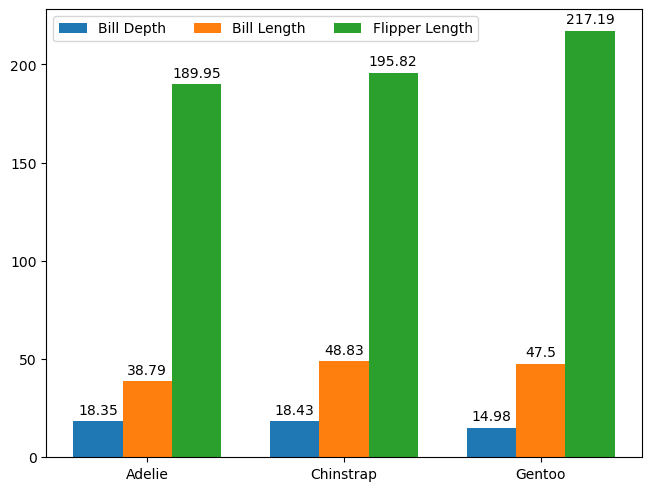

In [9]:
fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(species))
width = 0.25
multiplier = 0

for attribute, measurement in penguin_means.items():
    
    offset = width * multiplier
    bar_ticks = x + offset

    rects = ax.bar(bar_ticks, measurement, width,
                   label=attribute)
    ax.bar_label(rects, padding=3) # We can state the value of each bar explicitly on the plot
    
    multiplier += 1

ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3) # Add a legend for each bar's attribute

We can also display the standard errors of each measurement if available using the `yerr` argument of `ax.bar()`. Since each dictionary we defined in the data cell has the same attribute names, we just need to extract the `attribute` value from the `attribute_std_err` dictionary and the `for` loop will take care of proper assignment of each standard error value to each respective bar.

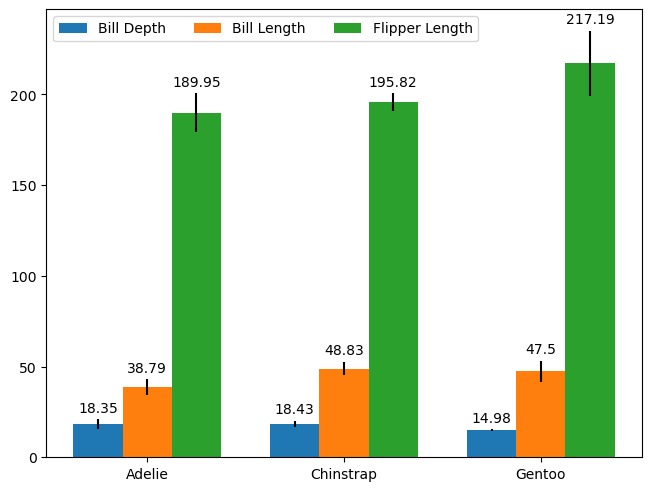

In [10]:
fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(species))
width = 0.25
multiplier = 0

for attribute, measurement in penguin_means.items():
    
    offset = width * multiplier
    bar_ticks = x + offset

    rects = ax.bar(bar_ticks, measurement, width,
                   label=attribute,
                   yerr=attribute_std_err[attribute])
    ax.bar_label(rects, padding=3)
    
    multiplier += 1

ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)

In this cell, we use the [starbars](https://github.com/elide-b/starbars) package to build on our plot. `starbars` takes statistical significance annotations as a list in the form `[(<bar_index_1>, <bar_index_2>, <significance value>), (...), ...]`. So for example, if bar 0 and bar 2 had a significance value of 0.0005, you would include the tuple `(0, 2, 0.0005)` within the annotation list like so `[(0, 2, 0.0005)]` with each subsequent annotations appended as new tuples within the list: `[(0, 2, 0.0005), (1, 2, 0.05), (...), ...]. It is important to note that Python is a 0-indexed language, and as such, bar indices are counted from 0 instead of 1.

Here, we use a Python [list comprehension](https://www.w3schools.com/python/python_lists_comprehension.asp) method to parse the input annotations for each bar of each group automatically. We could alternatively specify each annotation explicitly such as `starbars.draw_annotation([(bar0, bar2, sig1), (bar1, bar2, sig2), ...])`.

3.0250000000000004 0.03
3.0250000000000004 0.03
3.0250000000000004 0.03


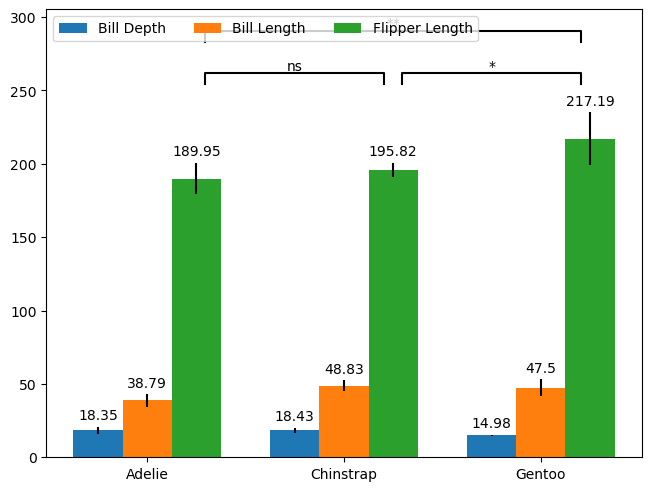

In [13]:
fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(species))
width = 0.25
multiplier = 0

for attribute, measurement in penguin_means.items():
    
    offset = width * multiplier
    bar_ticks = x + offset

    rects = ax.bar(bar_ticks, measurement, width,
                   label=attribute,
                   yerr=attribute_std_err[attribute])
    ax.bar_label(rects, padding=3)
    
    if annotations[attribute]: # only plot attribute annotations if they exist (i.e. are not an empty list)
        annot = [(bar_ticks[sig[0]], bar_ticks[sig[1]], sig[2]) for sig in annotations[attribute]]
        starbars.draw_annotation(annot)
    
    multiplier += 1

ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)

Lastly, we can refine our plot by adding a title, some labels, and changing the y-axis limit to accommodate the space taken up by the starbar annotations.

3.0250000000000004 0.03
3.0250000000000004 0.03
3.0250000000000004 0.03


(0.0, 350.0)

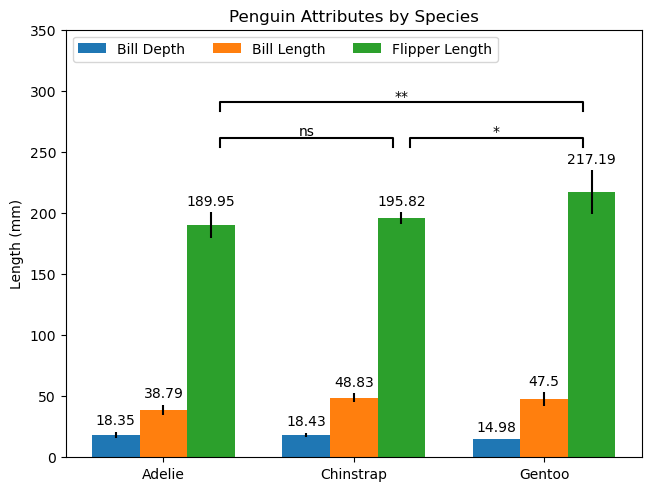

In [12]:
fig, ax = plt.subplots(layout='constrained')

x = np.arange(len(species))
width = 0.25
multiplier = 0

for attribute, measurement in penguin_means.items():
    
    offset = width * multiplier
    bar_ticks = x + offset

    rects = ax.bar(bar_ticks, measurement, width,
                   label=attribute,
                   yerr=attribute_std_err[attribute])
    ax.bar_label(rects, padding=3)
    
    if annotations[attribute]: # only plot attribute annotations if they exist (i.e. are not an empty list)
        annot = [(bar_ticks[sig[0]], bar_ticks[sig[1]], sig[2]) for sig in annotations[attribute]]
        starbars.draw_annotation(annot)
    
    multiplier += 1

ax.set_ylabel('Length (mm)')
ax.set_title('Penguin Attributes by Species')
ax.set_xticks(x + width, species)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 350)

- [An Interactive Guide to Hypothesis Testing in Python](https://towardsdatascience.com/an-interactive-guide-to-hypothesis-testing-in-python-979f4d62d85/)
- [More complex examples of how to use the starbars package](https://github.com/elide-b/starbars/tree/main/examples)
- Data from [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/) dataset